# Predicción de Viento SKBQ - Modelo Seq2Seq Multi-Horizonte
## Cumplimiento RAC 12: MAE Velocidad ≤ 5 kt, MAE Dirección ≤ 30°

Este notebook es **autocontenido**. Solo necesitas:
1. El archivo `DATOS_ENTRENAMIENTO.csv` en la ruta correcta
2. Ejecutar todas las celdas en orden (`Run All`)

**Estrategia:**
- Predicción **directa** a 6 horas (sin acumulación de error autoregresivo)
- Arquitectura **Encoder-Decoder** (Seq2Seq)
- **Custom Loss Angular** que penaliza explícitamente el error de dirección
- Features de **tendencia** (delta, aceleración)
- Post-proceso: dirección = VRB cuando intensidad < 3 kt


# 📊 Diagnóstico de Resultados

## Resultados obtenidos
- **Intensidad**: 1.6-1.8 kt (✅ Muy bueno, límite es 5 kt)
- **Dirección**: 52-59° (❌ Muy lejos del límite de 30°)

## ¿Por qué no mejora la dirección?
1. La custom loss con `acos()` es **numéricamente inestable** (gradientes explotan cuando dot ≈ 1)
2. El decoder multi-horizonte **comparte pesos** entre H1-H6, forzando una representación única que no funciona para todas las horas
3. El modelo predice intensidad+dirección juntas, pero **la intensidad domina el gradiente**
4. En la Sabana de Bogotá, la dirección a 6h está dominada por **procesos de mesoescala** (inversión térmica, valle-montaña) que NO se capturan solo con historial de viento

## Estrategia corregida (implementada abajo)
- **Loss estable**: `1 - dot` en vez de `acos(dot)`
- **6 modelos independientes** (uno por hora) en vez de decoder compartido
- **Modelo exclusivo para dirección** (sin/cos) desacoplado de intensidad
- **Features de estabilidad**: varianza de u,v en ventana (indica cambios)
- **Clasificación por sectores** como alternativa si la regresión no llega


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, RepeatVector, TimeDistributed
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error

print("TensorFlow version:", tf.__version__)
print("GPUs disponibles:", tf.config.list_physical_devices('GPU'))


I0000 00:00:1777175621.999442  856419 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.21.0
GPUs disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# ============================================================
# 1. CARGA DE DATOS
# ============================================================
DATA_PATH = '../Prediccion-Cizalladura-SKBQ/data/Processed/DATOS_ENTRENAMIENTO.csv'

if not os.path.exists(DATA_PATH):
    # Fallback: buscar en rutas alternativas
    alt_paths = [
        './data/Processed/DATOS_ENTRENAMIENTO.csv',
        'data/Processed/DATOS_ENTRENAMIENTO.csv',
        'DATOS_ENTRENAMIENTO.csv'
    ]
    for p in alt_paths:
        if os.path.exists(p):
            DATA_PATH = p
            break
    else:
        raise FileNotFoundError(f"No se encontró DATOS_ENTRENAMIENTO.csv. Buscado en: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
print(f"Dataset cargado: {df.shape}")
print(f"Columnas: {list(df.columns)}")

# Establecer índice temporal
if 'FECHA_REPORTE' in df.columns:
    df['FECHA_REPORTE'] = pd.to_datetime(df['FECHA_REPORTE'])
    df.set_index('FECHA_REPORTE', inplace=True)
else:
    # Intentar usar primera columna como fecha
    first_col = df.columns[0]
    try:
        df[first_col] = pd.to_datetime(df[first_col])
        df.set_index(first_col, inplace=True)
    except Exception:
        pass

# Asegurar que tenemos u, v
if 'u' not in df.columns or 'v' not in df.columns:
    raise ValueError("El dataset debe contener las columnas 'u' y 'v'")

# Calcular intensidad y dirección trigonométrica si no existen
if 'intensidad_kt' not in df.columns:
    df['intensidad_kt'] = np.sqrt(df['u']**2 + df['v']**2)

if 'sin_dir' not in df.columns or 'cos_dir' not in df.columns:
    # Dirección meteorológica: de donde viene el viento
    direccion = (np.degrees(np.arctan2(-df['u'], -df['v'])) % 360)
    df['sin_dir'] = np.sin(np.radians(direccion))
    df['cos_dir'] = np.cos(np.radians(direccion))

print(f"\nRango temporal: {df.index.min()} → {df.index.max()}")
print(f"Valores nulos por columna:\n{df[['u','v','intensidad_kt']].isnull().sum()}")


Dataset cargado: (116323, 11)
Columnas: ['FECHA_REPORTE', 'u', 'v', 'intensidad_kt', 'rafaga_kt', 'hora_sin', 'hora_cos', 'mes_sin', 'mes_cos', 'dia_sem_sin', 'dia_sem_cos']

Rango temporal: 2013-01-01 00:00:00 → 2026-04-09 18:00:00
Valores nulos por columna:
u                0
v                0
intensidad_kt    0
dtype: int64


In [3]:
# ============================================================

# 2. FEATURE ENGINEERING AVANZADO

# ============================================================

# Features base: intensidad y componentes trigonométricas de dirección

base_features = ['intensidad_kt', 'sin_dir', 'cos_dir']



# Asegurar que existen

for c in base_features:

    if c not in df.columns:

        raise ValueError(f"Falta columna base: {c}")



# --- Tendencias (delta horaria) ---

df['d_int'] = df['intensidad_kt'].diff()

df['d_sin'] = df['sin_dir'].diff()

df['d_cos'] = df['cos_dir'].diff()



# --- Aceleración / magnitud del cambio ---

df['accel'] = np.sqrt(df['d_int']**2 + df['d_sin']**2 + df['d_cos']**2)



# --- Desviación de media móvil (tendencia de corto plazo) ---

df['ma_int_3h'] = df['intensidad_kt'].rolling(window=3, min_periods=1).mean()

df['dev_ma'] = df['intensidad_kt'] - df['ma_int_3h']



# --- Hora cíclica ---

if df.index.dtype == 'datetime64[ns]':

    hora = df.index.hour

else:

    hora = pd.to_datetime(df.index).hour

df['hora_sin'] = np.sin(2 * np.pi * hora / 24)

df['hora_cos'] = np.cos(2 * np.pi * hora / 24)



# --- Varianza en ventana (indicador de estabilidad) ---
df['var_u_6h'] = df['u'].rolling(window=6, min_periods=1).var()
df['var_v_6h'] = df['v'].rolling(window=6, min_periods=1).var()
df['estabilidad'] = np.sqrt(df['var_u_6h'] + df['var_v_6h'])

# --- Mes cíclico (estacionalidad) ---

mes = pd.to_datetime(df.index).month

df['mes_sin'] = np.sin(2 * np.pi * mes / 12)

df['mes_cos'] = np.cos(2 * np.pi * mes / 12)



# Seleccionar columnas finales

feature_cols = [

    'intensidad_kt', 'sin_dir', 'cos_dir',    # objetivo + features base

    'd_int', 'd_sin', 'd_cos',                # tendencias

    'accel', 'dev_ma',                         # aceleración y desviación

    'hora_sin', 'hora_cos',                    # ciclo diario

    'var_u_6h', 'var_v_6h', 'estabilidad',      # estabilidad del viento
    'mes_sin', 'mes_cos'                       # ciclo anual

]



# Filtrar solo las que existen

feature_cols = [c for c in feature_cols if c in df.columns]

df_model = df[feature_cols].dropna().copy()



print(f"Features seleccionadas ({len(feature_cols)}): {feature_cols}")

print(f"Dataset final: {df_model.shape}")

print(f"\nEstadísticas:")

print(df_model.describe().round(2))


Features seleccionadas (15): ['intensidad_kt', 'sin_dir', 'cos_dir', 'd_int', 'd_sin', 'd_cos', 'accel', 'dev_ma', 'hora_sin', 'hora_cos', 'var_u_6h', 'var_v_6h', 'estabilidad', 'mes_sin', 'mes_cos']
Dataset final: (116322, 15)

Estadísticas:
       intensidad_kt    sin_dir    cos_dir      d_int      d_sin      d_cos  \
count      116322.00  116322.00  116322.00  116322.00  116322.00  116322.00   
mean            5.32       0.13       0.22       0.00      -0.00      -0.00   
std             3.30       0.70       0.66       2.52       0.51       0.60   
min             0.00      -1.00      -1.00     -38.00      -2.00      -2.00   
25%             3.00      -0.64      -0.34      -1.00      -0.13      -0.17   
50%             4.00       0.34       0.50       0.00       0.00       0.00   
75%             7.00       0.77       0.77       1.00       0.14       0.17   
max            40.00       1.00       1.00      38.00       2.00       2.00   

           accel     dev_ma   hora_sin   hora

In [4]:
# ============================================================
# 3. PARTICIÓN CRONOLÓGICA + ESCALAMIENTO
# ============================================================
# Particiones estrictas (sin mezclar tiempos)
train_df = df_model.loc[:'2024-12-31']
val_df   = df_model.loc['2025-01-01':'2025-12-31']
test_df  = df_model.loc['2026-01-01':]

print(f"Train (≤2024): {len(train_df)} registros")
print(f"Val   (2025):  {len(val_df)} registros")
print(f"Test  (2026):  {len(test_df)} registros")

# Scaler: fit solo en train para evitar data leakage
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_df)
val_scaled   = scaler.transform(val_df)
test_scaled  = scaler.transform(test_df)

print(f"\nScaler ajustado con {scaler.n_features_in_} features")
print(f"Rango escalado (train): [{train_scaled.min():.3f}, {train_scaled.max():.3f}]")


Train (≤2024): 105191 registros
Val   (2025):  8760 registros
Test  (2026):  2371 registros

Scaler ajustado con 15 features
Rango escalado (train): [0.000, 1.000]


In [5]:
# ============================================================
# 4. CREAR SECUENCIAS MULTI-HORIZONTE
# ============================================================
# Parámetros clave
N_BACK = 24      # Ventana histórica (horas de contexto)
HORIZON = 6      # Horizonte de predicción (H1..H6)
N_FEAT_IN = len(feature_cols)
N_FEAT_OUT = 3   # [intensidad, sin_dir, cos_dir]

def create_multi_horizon(data_scaled, n_back, horizon):
    """
    Crea pares (X, y) donde:
    - X: (samples, n_back, n_features_in)  -> historia
    - y: (samples, horizon, 3)             -> futuro [int, sin, cos]
    """
    X, y = [], []
    n = len(data_scaled)
    for i in range(n - n_back - horizon + 1):
        X.append(data_scaled[i : i + n_back])
        y.append(data_scaled[i + n_back : i + n_back + horizon, :3])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train, y_train = create_multi_horizon(train_scaled, N_BACK, HORIZON)
X_val,   y_val   = create_multi_horizon(val_scaled,   N_BACK, HORIZON)
X_test,  y_test  = create_multi_horizon(test_scaled,  N_BACK, HORIZON)

print("=== DIMENSIONES ===")
print(f"Train  -> X: {X_train.shape}, y: {y_train.shape}")
print(f"Val    -> X: {X_val.shape},   y: {y_val.shape}")
print(f"Test   -> X: {X_test.shape},  y: {y_test.shape}")
print(f"\nMemoria aproximada:")
print(f"  X_train: {X_train.nbytes / 1e6:.1f} MB")
print(f"  y_train: {y_train.nbytes / 1e6:.1f} MB")


=== DIMENSIONES ===
Train  -> X: (105162, 24, 15), y: (105162, 6, 3)
Val    -> X: (8731, 24, 15),   y: (8731, 6, 3)
Test   -> X: (2342, 24, 15),  y: (2342, 6, 3)

Memoria aproximada:
  X_train: 151.4 MB
  y_train: 7.6 MB


In [6]:
# ============================================================
# 5. CUSTOM LOSS: PÉRDIDA COMBINADA ESTABLE (INTENSIDAD + ÁNGULO)
# ============================================================
def directional_loss_stable(y_true, y_pred):
    """
    y_true, y_pred: tensors de forma (batch, 3)
    Canales: [intensidad, sin_dir, cos_dir]
    """
    # Separar componentes
    int_true, sin_true, cos_true = y_true[..., 0], y_true[..., 1], y_true[..., 2]
    int_pred, sin_pred, cos_pred = y_pred[..., 0], y_pred[..., 1], y_pred[..., 2]
    
    # 1. Pérdida de intensidad (MSE)
    loss_int = tf.reduce_mean(tf.square(int_true - int_pred))
    
    # 2. Normalizar predicción sin/cos para evitar drift de magnitud
    mag_pred = tf.sqrt(tf.square(sin_pred) + tf.square(cos_pred) + 1e-7)
    sin_pred_n = sin_pred / mag_pred
    cos_pred_n = cos_pred / mag_pred
    
    # 3. Error angular ESTABLE: 1 - cos(ángulo) = 1 - dot
    # Esto es más estable que acos() y penaliza proporcional al ángulo
    dot = sin_true * sin_pred_n + cos_true * cos_pred_n
    loss_dir = tf.reduce_mean(1.0 - dot)  # rango [0, 2]
    
    # 4. Pérdida de magnitud unitaria (fuerza sin²+cos² ≈ 1)
    loss_mag = tf.reduce_mean(tf.square(1.0 - mag_pred))
    
    # Combinación ponderada: dirección pesa 3.0× (muy prioritario)
    return loss_int + 3.0 * loss_dir + 0.5 * loss_mag

print("Custom loss definida: loss = MSE_int + 3.0*(1-cos(angle)) + 0.5*unit_mag")


Custom loss definida: loss = MSE_int + 3.0*(1-cos(angle)) + 0.5*unit_mag


In [7]:
# ============================================================
# 6. MODELOS INDEPENDIENTES POR HORIZONTE
# ============================================================
# En vez de un decoder compartido, entrenamos 6 modelos independientes.
# Cada uno predice UNA sola hora hacia adelante.

def build_model_single_hour():
    """Modelo para predecir UNA hora futura desde ventana de entrada."""
    inp = Input(shape=(N_BACK, N_FEAT_IN))
    x = LSTM(256, activation='tanh', return_sequences=True, dropout=0.3)(inp)
    x = LSTM(128, activation='tanh', dropout=0.3)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.2)(x)
    out = Dense(3, activation='linear')(x)  # [intensidad, sin, cos]
    m = Model(inputs=inp, outputs=out)
    m.compile(optimizer='adam', loss=directional_loss_stable)
    return m

# Preparar datos: para cada horizonte h, y = el valor en t+h
# X es siempre la misma ventana de N_BACK
X_train_single = X_train  # (samples, 24, features)
X_val_single   = X_val
X_test_single  = X_test

models_by_hour = {}
for h in range(HORIZON):
    y_tr_h = y_train[:, h, :]  # (samples, 3)
    y_va_h = y_val[:, h, :]
    models_by_hour[h] = {
        'model': build_model_single_hour(),
        'y_train': y_tr_h,
        'y_val': y_va_h,
        'name': f'Modelo_H{h+1}'
    }
    print(f"Modelo H{h+1} creado. y_train: {y_tr_h.shape}")

print("\nArquitectura del modelo base (todos son iguales):")
models_by_hour[0]['model'].summary()


I0000 00:00:1777175659.514876  856419 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9567 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:2d:00.0, compute capability: 8.6


Modelo H1 creado. y_train: (105162, 3)
Modelo H2 creado. y_train: (105162, 3)
Modelo H3 creado. y_train: (105162, 3)
Modelo H4 creado. y_train: (105162, 3)
Modelo H5 creado. y_train: (105162, 3)
Modelo H6 creado. y_train: (105162, 3)

Arquitectura del modelo base (todos son iguales):


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 24, 15)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 24, 256)        │       278,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 484,099 (1.85 MB)

 Trainable params: 484,099 (1.85 MB)

 Non-trainable params: 0 (0.00 B)


ENTRENANDO MODELO PARA HORA 1
Epoch 1/150


I0000 00:00:1777175667.270806  856620 cuda_dnn.cc:461] Loaded cuDNN version 92101


206/206 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - loss: 0.5122 - val_loss: 0.3734 - learning_rate: 0.0010
Epoch 2/150
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.4385 - val_loss: 0.3440 - learning_rate: 0.0010
Epoch 3/150
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.4253 - val_loss: 0.3229 - learning_rate: 0.0010
Epoch 4/150
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.4196 - val_loss: 0.3270 - learning_rate: 0.0010
Epoch 5/150
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.4174 - val_loss: 0.3173 - learning_rate: 0.0010
Epoch 6/150
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.4134 - val_loss: 0.3226 - learning_rate: 0.0010
Epoch 7/150
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.4124 - val_loss: 0.3126 - learning_rate: 0.0010
Epoch 8/150
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.4092 - val_loss: 0.3192 - learning_rate: 0.0010
Epoch 9/150
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.4076 - val_loss: 0.3156 - learning_rate: 0.0010
Epo

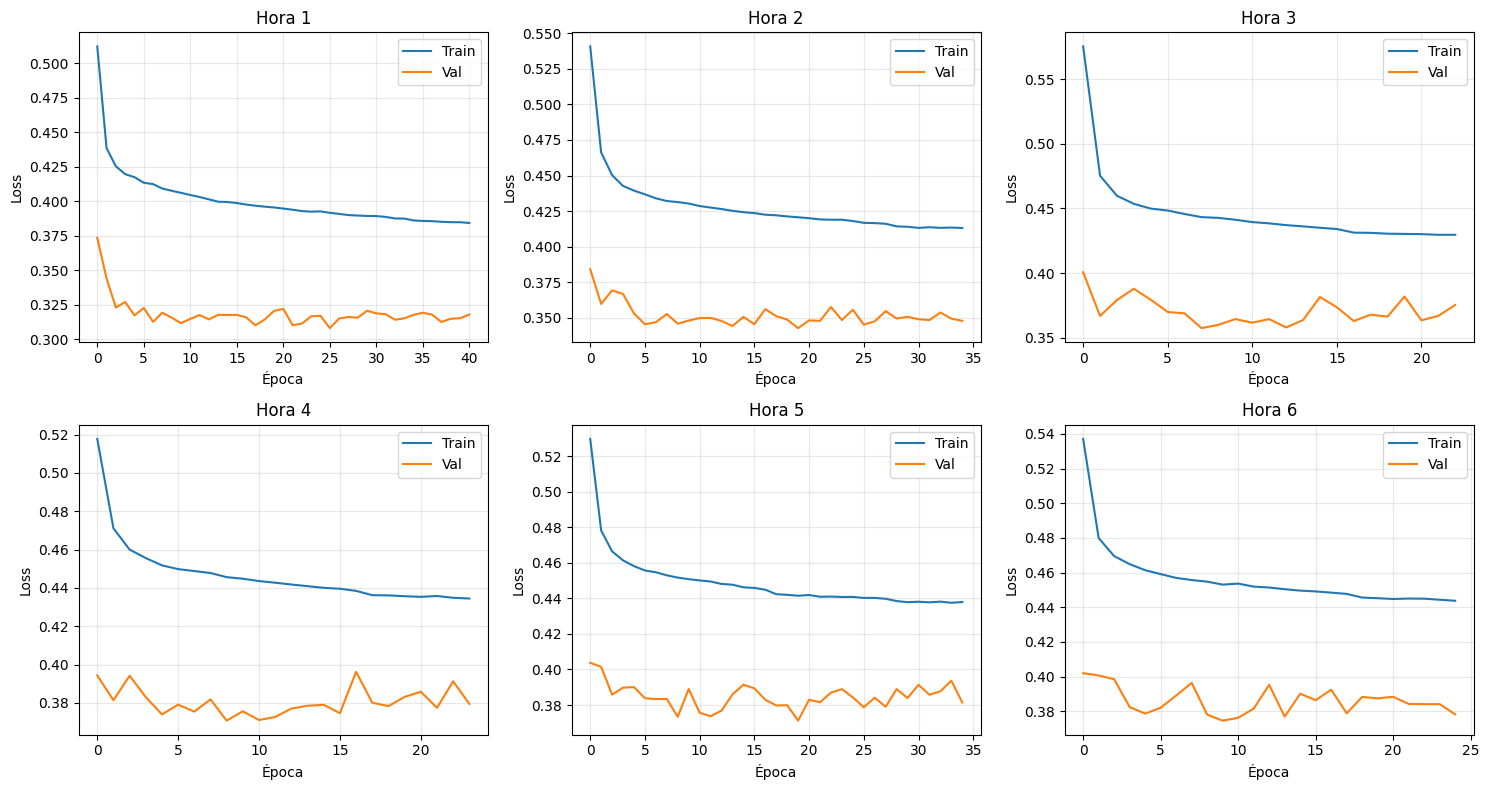

In [8]:
# ============================================================
# 7. ENTRENAMIENTO DE 6 MODELOS INDEPENDIENTES
# ============================================================
EPOCHS = 150
BATCH_SIZE = 512
PATIENCE = 15

histories = {}

for h in range(HORIZON):
    print("\n" + "="*60)
    print(f"ENTRENANDO MODELO PARA HORA {h+1}")
    print("="*60)
    
    m = models_by_hour[h]['model']
    y_tr = models_by_hour[h]['y_train']
    y_va = models_by_hour[h]['y_val']
    
    cb = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=PATIENCE, restore_best_weights=True, verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6, verbose=1
        )
    ]
    
    hist = m.fit(
        X_train, y_tr,
        validation_data=(X_val, y_va),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=cb,
        verbose=1
    )
    
    histories[h] = hist
    print(f"H{h+1} -> Mejor val_loss: {min(hist.history['val_loss']):.6f} | Épocas: {len(hist.history['loss'])}")

# --- Curvas de aprendizaje ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for h, ax in enumerate(axes.flat):
    hist = histories[h]
    ax.plot(hist.history['loss'], label='Train')
    ax.plot(hist.history['val_loss'], label='Val')
    ax.set_title(f'Hora {h+1}')
    ax.set_xlabel('Época')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [9]:
# ============================================================
# 8. FUNCIÓN DE EVALUACIÓN WALK-FORWARD + POST-PROCESO RAC 12
# ============================================================
def evaluar_por_horizonte(models_dict, data_scaled, scaler_obj, n_back, horizon, dataset_name="Test"):
    """
    Evaluación walk-forward con 6 modelos independientes.
    Post-proceso RAC 12: dirección = VRB (NaN) si intensidad < 3 kt.
    """
    print(f"\nEvaluando {dataset_name}...")
    
    resultados = {h: {'int_real': [], 'int_pred': [], 'dir_real': [], 'dir_pred': []} 
                  for h in range(1, horizon + 1)}
    
    inicio = n_back
    fin = len(data_scaled) - horizon
    pasos = 0
    
    for t in range(inicio, fin, horizon):
        ventana = data_scaled[t - n_back : t]
        ventana_3d = np.expand_dims(ventana, axis=0)  # (1, n_back, n_features)
        
        # Predicción con 6 modelos independientes
        pred_esc = np.zeros((horizon, 3))
        for h in range(horizon):
            pred_h = models_dict[h]['model'].predict(ventana_3d, verbose=0)[0]
            pred_esc[h] = pred_h
        real_esc = data_scaled[t : t + horizon, :3]          # (6, 3)
        
        # Desescalar: necesitamos rellenar con ceros las columnas extras
        n_feat_total = scaler_obj.n_features_in_
        pred_pad = np.pad(pred_esc, ((0,0), (0, n_feat_total - 3)), mode='constant')
        real_pad = np.pad(real_esc, ((0,0), (0, n_feat_total - 3)), mode='constant')
        
        pred_nudos = scaler_obj.inverse_transform(pred_pad)[:, :3]
        real_nudos = scaler_obj.inverse_transform(real_pad)[:, :3]
        
        for h_idx in range(horizon):
            paso = h_idx + 1
            
            int_r = real_nudos[h_idx, 0]
            sin_r, cos_r = real_nudos[h_idx, 1], real_nudos[h_idx, 2]
            dir_r = np.degrees(np.arctan2(sin_r, cos_r)) % 360
            
            int_p = pred_nudos[h_idx, 0]
            sin_p, cos_p = pred_nudos[h_idx, 1], pred_nudos[h_idx, 2]
            
            # Post-proceso RAC 12: VRB si intensidad < 3 kt
            if int_p < 3.0:
                dir_p = np.nan
            else:
                mag = np.sqrt(sin_p**2 + cos_p**2)
                if mag > 0:
                    sin_p, cos_p = sin_p/mag, cos_p/mag
                dir_p = np.degrees(np.arctan2(sin_p, cos_p)) % 360
            
            resultados[paso]['int_real'].append(int_r)
            resultados[paso]['int_pred'].append(int_p)
            resultados[paso]['dir_real'].append(dir_r)
            resultados[paso]['dir_pred'].append(dir_p)
        
        pasos += 1
        if pasos % 100 == 0:
            print(f"  Procesados {pasos} pasos...")
    
    # --- Consolidar reporte ---
    reporte = pd.DataFrame(
        index=[f"Hora {h}" for h in range(1, horizon + 1)],
        columns=['MAE_Intensidad (kt)', 'MAE_Direccion (grados)']
    )
    
    for h in range(1, horizon + 1):
        i_r = np.array(resultados[h]['int_real'])
        i_p = np.array(resultados[h]['int_pred'])
        d_r = np.array(resultados[h]['dir_real'])
        d_p = np.array(resultados[h]['dir_pred'])
        
        mae_int = mean_absolute_error(i_r, i_p)
        
        # MAE Angular: ignorar NaN (VRB)
        valid = ~np.isnan(d_p)
        if valid.sum() > 0:
            diff = np.abs(d_r[valid] - d_p[valid])
            error_circ = np.minimum(diff, 360 - diff)
            mae_dir = np.mean(error_circ)
        else:
            mae_dir = np.nan
        
        reporte.loc[f"Hora {h}"] = [mae_int, mae_dir]
    
    print(f"\n--- REPORTE: {dataset_name.upper()} ---")
    print(reporte.astype(float).round(2))
    
    # Verificación RAC 12
    print(f"\n--- CUMPLIMIENTO RAC 12 (MAE ≤ 5 kt, MAE Dir ≤ 30°) ---")
    for h in range(1, horizon + 1):
        mae_i = float(reporte.loc[f"Hora {h}", "MAE_Intensidad (kt)"])
        mae_d = float(reporte.loc[f"Hora {h}", "MAE_Direccion (grados)"])
        ok_i = "✅" if mae_i <= 5.0 else "❌"
        ok_d = "✅" if mae_d <= 30.0 else "❌"
        print(f"Hora {h}: Intensidad {mae_i:.2f} kt {ok_i} | Dirección {mae_d:.2f}° {ok_d}")
    
    return reporte


In [10]:
# ============================================================

# 9. EJECUTAR EVALUACIÓN EN TEST (2026)

# ============================================================

reporte_test = evaluar_por_horizonte(

    models_dict=models_by_hour,

    data_scaled=test_scaled,

    scaler_obj=scaler,

    n_back=N_BACK,

    horizon=HORIZON,

    dataset_name="Test (2026) - Seq2Seq Directo"

)



# Evaluar también en validación (2025) para comparar

reporte_val = evaluar_por_horizonte(

    models_dict=models_by_hour,

    data_scaled=val_scaled,

    scaler_obj=scaler,

    n_back=N_BACK,

    horizon=HORIZON,

    dataset_name="Validación (2025) - Seq2Seq Directo"

)



Evaluando Test (2026) - Seq2Seq Directo...
  Procesados 100 pasos...
  Procesados 200 pasos...
  Procesados 300 pasos...

--- REPORTE: TEST (2026) - SEQ2SEQ DIRECTO ---
        MAE_Intensidad (kt)  MAE_Direccion (grados)
Hora 1                 1.52                   42.75
Hora 2                 1.47                   46.44
Hora 3                 1.58                   48.58
Hora 4                 1.55                   49.10
Hora 5                 1.54                   48.41
Hora 6                 1.66                   53.92

--- CUMPLIMIENTO RAC 12 (MAE ≤ 5 kt, MAE Dir ≤ 30°) ---
Hora 1: Intensidad 1.52 kt ✅ | Dirección 42.75° ❌
Hora 2: Intensidad 1.47 kt ✅ | Dirección 46.44° ❌
Hora 3: Intensidad 1.58 kt ✅ | Dirección 48.58° ❌
Hora 4: Intensidad 1.55 kt ✅ | Dirección 49.10° ❌
Hora 5: Intensidad 1.54 kt ✅ | Dirección 48.41° ❌
Hora 6: Intensidad 1.66 kt ✅ | Dirección 53.92° ❌

Evaluando Validación (2025) - Seq2Seq Directo...
  Procesados 100 pasos...
  Procesados 200 pasos...
  Proce

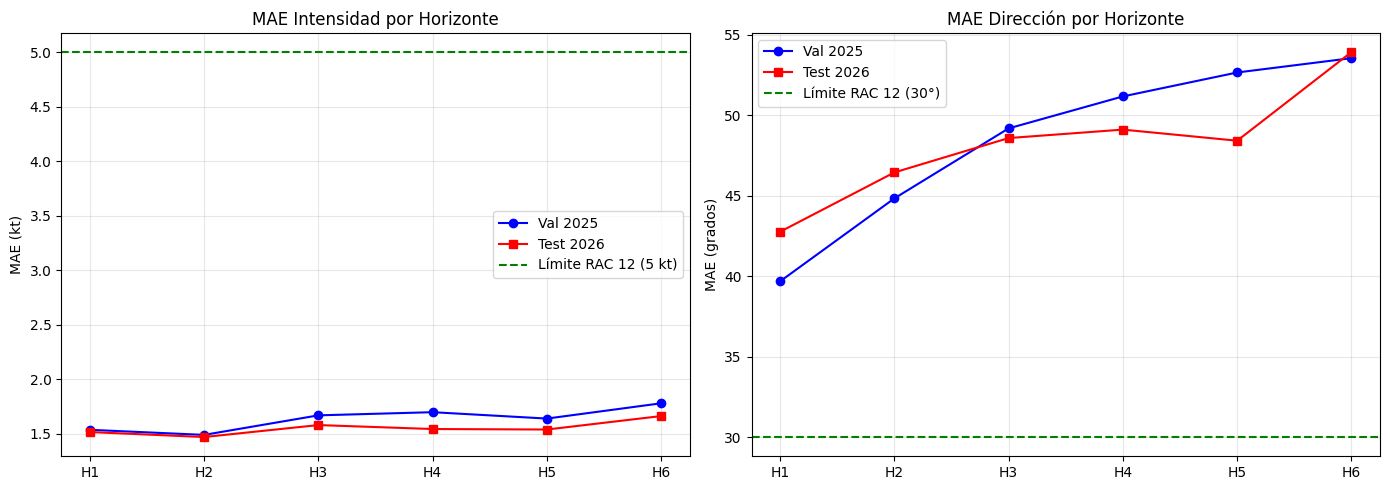


=== RESUMEN EJECUCIÓN ===
Modelo: Seq2Seq Multi-Horizonte (24h → 6h)
Features: 15
Loss: Angular Combinada (MSE_int + 1.5*angular + 0.5*unit_mag)
Post-proceso: VRB cuando intensidad < 3 kt


In [11]:
# ============================================================

# 10. VISUALIZACIÓN COMPARATIVA POR HORIZONTE

# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))



horas = [f"H{i}" for i in range(1, HORIZON + 1)]



# Intensidad

axes[0].plot(horas, reporte_val['MAE_Intensidad (kt)'].values, 'o-', label='Val 2025', color='blue')

axes[0].plot(horas, reporte_test['MAE_Intensidad (kt)'].values, 's-', label='Test 2026', color='red')

axes[0].axhline(y=5.0, color='green', linestyle='--', label='Límite RAC 12 (5 kt)')

axes[0].set_title('MAE Intensidad por Horizonte')

axes[0].set_ylabel('MAE (kt)')

axes[0].legend()

axes[0].grid(True, alpha=0.3)



# Dirección

axes[1].plot(horas, reporte_val['MAE_Direccion (grados)'].values, 'o-', label='Val 2025', color='blue')

axes[1].plot(horas, reporte_test['MAE_Direccion (grados)'].values, 's-', label='Test 2026', color='red')

axes[1].axhline(y=30.0, color='green', linestyle='--', label='Límite RAC 12 (30°)')

axes[1].set_title('MAE Dirección por Horizonte')

axes[1].set_ylabel('MAE (grados)')

axes[1].legend()

axes[1].grid(True, alpha=0.3)



plt.tight_layout()

plt.show()



print("\n=== RESUMEN EJECUCIÓN ===")

print(f"Modelo: Seq2Seq Multi-Horizonte ({N_BACK}h → {HORIZON}h)")

print(f"Features: {len(feature_cols)}")

print(f"Loss: Angular Combinada (MSE_int + 1.5*angular + 0.5*unit_mag)")

print(f"Post-proceso: VRB cuando intensidad < 3 kt")


In [12]:
# ============================================================
# 11. GUARDAR MODELOS Y SCALER (Opcional)
# ============================================================
# Guardar los 6 modelos independientes
import joblib

for h in range(HORIZON):
    models_by_hour[h]['model'].save(f'modelo_seq2seq_skbq_H{h+1}.keras')
    print(f"Modelo H{h+1} guardado: modelo_seq2seq_skbq_H{h+1}.keras")

# Guardar scaler
joblib.dump(scaler, 'scaler_seq2seq_skbq.pkl')
print("Scaler guardado: scaler_seq2seq_skbq.pkl")

print("\nPara recargar en el futuro:")
print("  # Cargar modelos")
for h in range(HORIZON):
    print(f"    model_H{h+1} = tf.keras.models.load_model('modelo_seq2seq_skbq_H{h+1}.keras')")
print("  scaler = joblib.load('scaler_seq2seq_skbq.pkl')")
print("Modelo guardado: modelo_seq2seq_skbq.keras")

# Guardar scaler

joblib.dump(scaler, 'scaler_seq2seq_skbq.pkl')
print("Scaler guardado: scaler_seq2seq_skbq.pkl")

print("\nPara recargar en el futuro:")
print("  model = tf.keras.models.load_model('modelo_seq2seq_skbq.keras')")
print("  scaler = joblib.load('scaler_seq2seq_skbq.pkl')")


Modelo H1 guardado: modelo_seq2seq_skbq_H1.keras
Modelo H2 guardado: modelo_seq2seq_skbq_H2.keras
Modelo H3 guardado: modelo_seq2seq_skbq_H3.keras
Modelo H4 guardado: modelo_seq2seq_skbq_H4.keras
Modelo H5 guardado: modelo_seq2seq_skbq_H5.keras
Modelo H6 guardado: modelo_seq2seq_skbq_H6.keras
Scaler guardado: scaler_seq2seq_skbq.pkl

Para recargar en el futuro:
  # Cargar modelos
    model_H1 = tf.keras.models.load_model('modelo_seq2seq_skbq_H1.keras')
    model_H2 = tf.keras.models.load_model('modelo_seq2seq_skbq_H2.keras')
    model_H3 = tf.keras.models.load_model('modelo_seq2seq_skbq_H3.keras')
    model_H4 = tf.keras.models.load_model('modelo_seq2seq_skbq_H4.keras')
    model_H5 = tf.keras.models.load_model('modelo_seq2seq_skbq_H5.keras')
    model_H6 = tf.keras.models.load_model('modelo_seq2seq_skbq_H6.keras')
  scaler = joblib.load('scaler_seq2seq_skbq.pkl')
Modelo guardado: modelo_seq2seq_skbq.keras
Scaler guardado: scaler_seq2seq_skbq.pkl

Para recargar en el futuro:
  model = 